In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=["ID", "Entity", "Sentiment", "Tweet"]
)
df

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [ ]:
df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [ ]:
df.shape

(74682, 4)

In [ ]:
df.columns

Index(['ID', 'Entity', 'Sentiment', 'Tweet'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [ ]:
df.isnull().sum()

,0
ID,0
Entity,0
Sentiment,0
Tweet,686


In [ ]:
df.duplicated().sum()

np.int64(2700)

In [ ]:
df = df.dropna()

In [ ]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,22358
Positive,20655
Neutral,18108
Irrelevant,12875


/tmp/ipykernel_1276/2381834100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


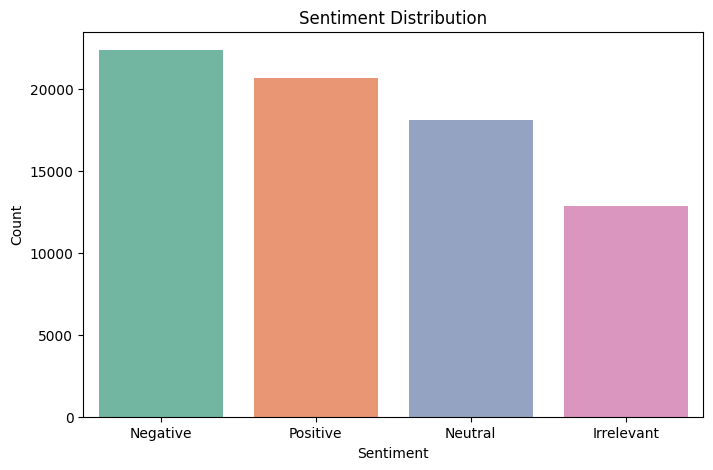

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index,
    palette="Set2"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

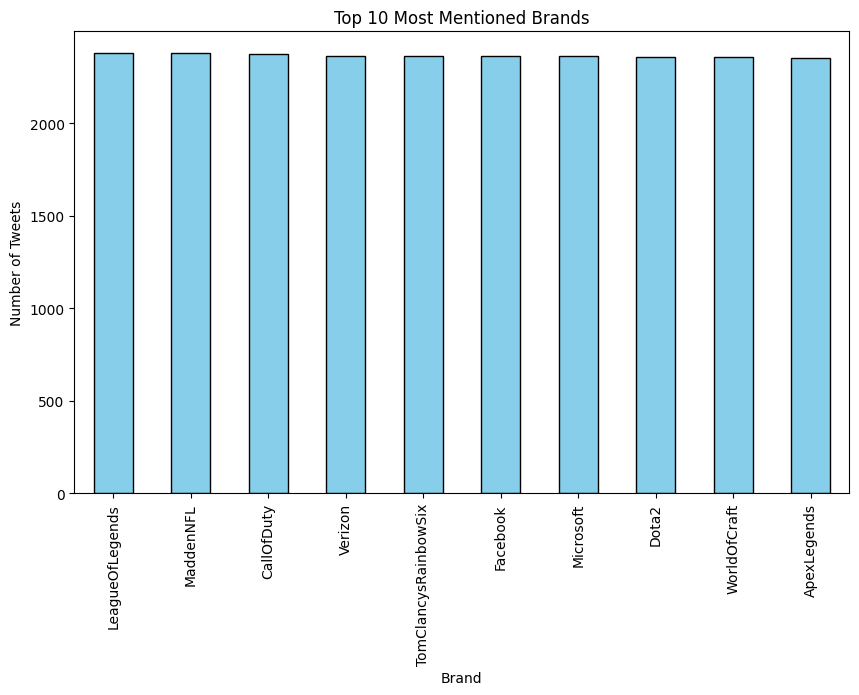

In [ ]:
plt.figure(figsize=(10,6))

df["Entity"].value_counts().head(10).plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Top 10 Most Mentioned Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Tweets")

plt.show()

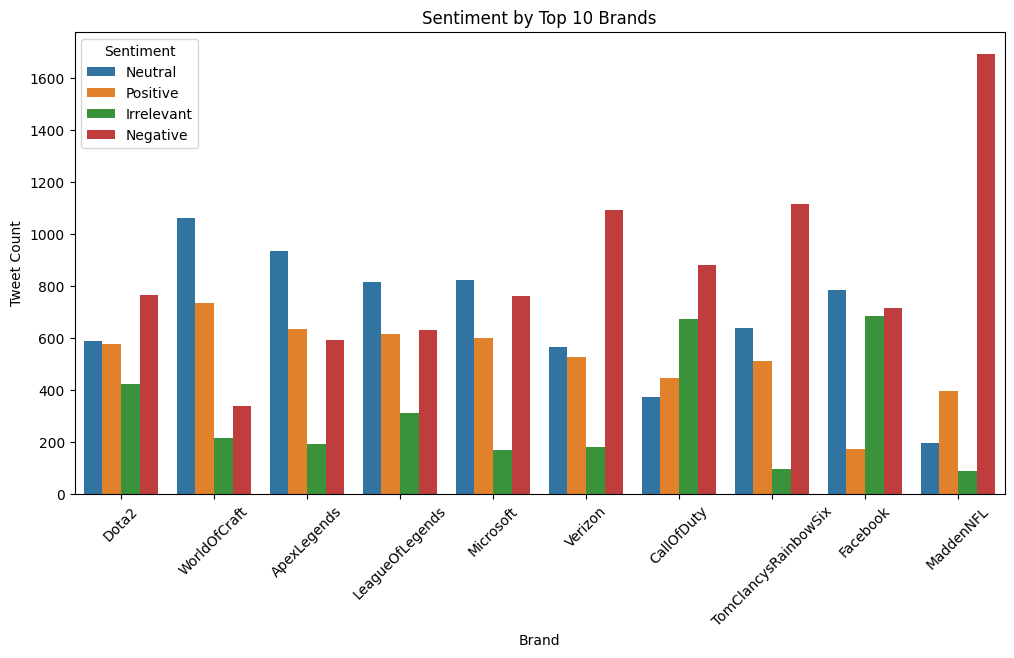

In [ ]:
top_brands = df["Entity"].value_counts().head(10).index

brand_sentiment = df[df["Entity"].isin(top_brands)]

plt.figure(figsize=(12,6))

sns.countplot(
    data=brand_sentiment,
    x="Entity",
    hue="Sentiment"
)

plt.title("Sentiment by Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Tweet Count")
plt.xticks(rotation=45)

plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["Tweet"])

y = df["Sentiment"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8424324324324325


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Irrelevant       0.90      0.77      0.83      2696
    Negative       0.86      0.87      0.87      4380
     Neutral       0.87      0.80      0.84      3605
    Positive       0.78      0.89      0.83      4119

    accuracy                           0.84     14800
   macro avg       0.85      0.83      0.84     14800
weighted avg       0.85      0.84      0.84     14800



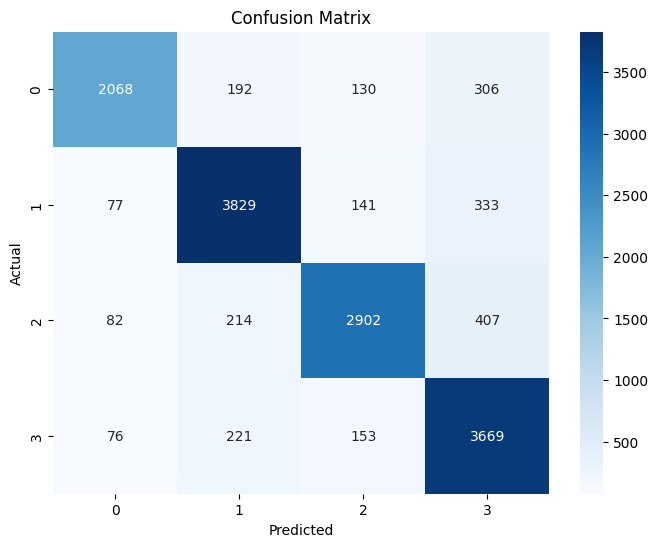

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index,
    palette="Set2")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
plt.figure(figsize=(10,6))
df["Entity"].value_counts().head(10).plot(
    kind="bar",
    color="skyblue",
    edgecolor="black")
plt.title("Top 10 Most Mentioned Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Tweets")
plt.show()
top_brands = df["Entity"].value_counts().head(10).index
brand_sentiment = df[df["Entity"].isin(top_brands)]
plt.figure(figsize=(12,6))
sns.countplot(
    data=brand_sentiment,
    x="Entity",
    hue="Sentiment")
plt.title("Sentiment by Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Tweet Count")
plt.xticks(rotation=45)
plt.show()